In [1]:
library(ggplot2)
library(tidyverse)

── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../'
outdir = '../plots'

In [3]:
data<-read.csv(paste0(indir,'/PCC_df_le2_se50.csv'), row.names=1)
head(data);dim(data)

,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,PCC_5hmCG_RNA
,<chr>,<int>,<chr>,<dbl>,<dbl>
0,chr1,463,ENSMUSG00000002459.17,-0.1732788,-0.1642807
1,chr1,641,ENSMUSG00000033740.17,0.1608042,-0.3793481
2,chr1,1024,ENSMUSG00000042501.12,-0.1875811,-0.1929578
3,chr1,1074,ENSMUSG00000042501.12,0.2361129,-0.1172625
4,chr1,1083,ENSMUSG00000048960.13,0.3663292,-0.0120595
6,chr1,1198,ENSMUSG00000057715.13,0.4041402,0.5628185


[1] 17732     5

In [4]:
options(repr.plot.width=36/25.4,repr.plot.height=36/25.4,repr.plot.res=400)

In [7]:
data$'group'=sapply(data$'PCC_3C_RNA'>0.5, function(a){if(a){return('PCC(3C interaction, RNA)>0.5')}else{return('others')}})
# Change the order of the factor levels
data$'group' <- factor(data$'group', levels = c('PCC(3C interaction, RNA)>0.5', 'others'))

In [17]:
group1 <- data$PCC_5hmCG_RNA[data$group == "PCC(3C interaction, RNA)>0.5"]
group2 <- data$PCC_5hmCG_RNA[data$group == "others"]

breaks <- seq(-1, 1, by = 0.10)   # using bins of width 0.1 to get the probability distribution for the KL-divergence

# Convert histograms to probability distributions
p_hist <- hist(group1, breaks = breaks, plot = FALSE)
q_hist <- hist(group2, breaks = breaks, plot = FALSE)

# Probabilities
p <- p_hist$counts / sum(p_hist$counts)
q <- q_hist$counts / sum(q_hist$counts)

eps <- 1e-16
p <- p + eps
q <- q + eps

# Renormalize
p <- p / sum(p)
q <- q / sum(q)

kl_discrete <- function(P, Q) {
  sum(P * log(P / Q))
}

kl_value <- kl_discrete(p, q)
kl_value

[1] 0.1872247

In [19]:
p<-ggplot(data, aes(x = PCC_5hmCG_RNA, group = group, color = group,alpha=group)) +
geom_density(aes(alpha=group)) +
geom_area(stat = "density", aes(y = ..density..,alpha=group),fill="#FFA500" ,position = "identity")+ # using geom_area to simulate the shadow 
scale_alpha_manual(values = c('PCC(3C interaction, RNA)>0.5' = 0.3, 'others' = 0.01)) +# setting the alpha values individually
scale_color_manual(values = c('PCC(3C interaction, RNA)>0.5' = "#DB9980", 'others' = "#97a0a6"))+
scale_x_continuous(breaks=c(-1,-0.5,0,0.5,1),limit=c(-1,1))+
# scale_y_continuous(breaks = seq(from = 0, to = 85, by = 20), limits = c(0, 85))+
# geom_vline(xintercept = quantiles, linetype = "dashed", color = "#c9d6df",size=0.5) +
labs(x ="PCC(5hmCG%, RNA)" ,y="Density")+
geom_text(aes(label='KL = 0.187',family="ArialMT",fontface='plain'),x=-0.5,y=1.3,size=2,color='black')+
theme_bw()+
theme(legend.position="none",
legend.title = element_text(size = 6),  # Change legend title size
legend.text = element_text(size = 6),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=6,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=6,family="ArialMT"),
axis.title.y = element_text(color="black", size=6,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())

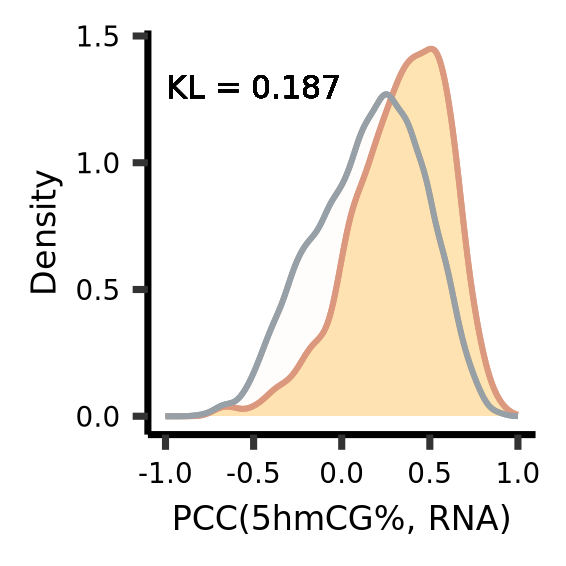

In [20]:
p

In [21]:
pdf(paste0(outdir, '/05_PCC(5hmCG,RNA)_density_plot.pdf'), width=36/25.4,height=36/25.4, family="ArialMT")
print(p)
dev.off()

agg_record_494447651 
                   2